<div align="center">

<img src="https://raw.githubusercontent.com/FarhadBagheri23/SoC-Estimation-EV-Batteries-LSTM/main/assets/sharif-logo.jpg" width="115" alt="Sharif University of Technology">

<font color="#0F5298" size="6"><b>State-of-Charge Estimation for EV Lithium-Ion Batteries</b></font>

<font color="#0F5298" size="4">A controlled comparison of deep learning architectures on the LG 18650HG2 cell</font>

<b>Sharif University of Technology — International Campus, Kish Island</b><br>
B.Sc. Thesis Project · Department of Computer Engineering · 2026<br>
<b>Farhad Bagheri Taheri</b> &nbsp;·&nbsp; Supervisor: <b>Dr. Amin Foshati</b>

</div>

---

### Motivation

A battery management system (BMS) reports State of Charge, but it cannot *measure*
it — no sensor reads SoC directly. The BMS infers it, almost always by Coulomb
counting: integrating the measured current over time. Integration means that any
error in the current sensor is **accumulated rather than averaged away**. A 20 mA
offset on a 3 Ah cell is invisible in any single sample and becomes several percent
of SoC over an hour.

Inferring SoC from the measured signals directly avoids that accumulation, but two
properties of the cell make it genuinely hard. The relationship between terminal
voltage and charge state is weak across the middle of the usable window, so a single
reading carries little information; and that relationship shifts substantially with
temperature, so the mapping is different at each end of the operating range. Both
push toward a model that reads a *window* of recent history and is conditioned on
temperature, which is what the architectures compared here do.

### What this notebook establishes

Six estimators are trained under one data pipeline, one training procedure and
comparable parameter budgets, and each is trained three times from different random
initialisations. The repetition is the point: the spread across seeds can exceed the
difference between two architectures (Vidal et al., 2020), so a comparison based on a
single run per model measures initialisation luck as much as design quality.

### Pipeline

① exploratory analysis → ② preprocessing, labelling and leakage-free windowing →
③ six architectures trained across seeds → ④ error analysis by temperature and across
the charge window → ⑤ validity audit of the labels and of the ranking.

### Literature used

| # | Reference (full list in the final section) | Contribution to this work |
|---|---|---|
| 1 | Kollmeyer et al. (2020) | the dataset |
| 2 | Chemali et al. (2018) | sliding-window LSTM formulation for SoC |
| 3 | Song et al. (2019) | CNN-LSTM architecture |
| 4 | Mamo & Wang (2020) | LSTM with attention |
| 5 | Vidal et al. (2020) | comparison methodology: equal parameter budgets, repeated training runs |
| 6 | Terala et al. (2022) | stacked bidirectional LSTM |
| 7 | Khan et al. (2024) | CNN-Bi-LSTM hybrid design |
| 8 | Li et al. (2026) | CNN-Bi-LSTM with attention under low temperature |
| 9 | Benallal et al. (2025) | LSTM benchmark figures on this dataset |
| 10 | Ma et al. (2025) | multi-task SoC estimation with a reconstruction head |
| 11 | Lee et al. (2025) | systematic data screening in battery prognostics |
| 12 | Haraz et al. (2024) | SoC/SoH machine-learning survey |


## 1 · Setup and configuration

A single configuration dictionary drives the whole notebook, so every hyperparameter
is visible in one place and reproducible.

The estimator settings follow the established LG 18650HG2 literature: 100-step input
windows at 1 Hz, matching the sliding-window formulation of Chemali et al. (2018), and
a hidden size of 128 across all recurrent models so that parameter counts stay
comparable — the fair-comparison requirement set out by Vidal et al. (2020).

In [2]:
# ---- setup -------------------------------------------------------------
import os, io, json, math, time, random, urllib.request, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3,
                     'axes.spines.top': False, 'axes.spines.right': False})

CFG = dict(
    # --- signal conditioning --------------------------------------------
    target_hz   = 1.0,    # every file is resampled to this rate
    roll_long   = 300,    # long rolling-average window for context features (s)
    roll_short  = 60,     # short rolling-average window (s)

    # --- estimator ------------------------------------------------------
    seq_len     = 100,    # timesteps of history fed to the sequence models
    stride      = 1,      # set from dataset size in section 5
    batch_size  = 256,
    epochs      = 40,
    lr          = 1e-3,
    hidden      = 128,
    patience    = 6,      # early-stopping patience, in epochs
    seed        = 42,
    n_seeds     = 3,      # training repeats per architecture
)

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)

set_seed(CFG['seed'])
DEV = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('torch', torch.__version__, '| device:', DEV)
if DEV.type == 'cuda':
    print('gpu   ', torch.cuda.get_device_name(0))

torch 2.11.0+cu128 | device: cuda
gpu    Tesla T4


## 2 · Data — the LG 18650HG2 benchmark

The experiments use the McMaster University benchmark published by Kollmeyer et al.
(2020): a 3 Ah LG 18650HG2 lithium-ion cell cycled inside a thermal chamber at six
ambient temperatures spanning −20 °C to +40 °C, driven through standard automotive
drive cycles (UDDS, LA92, US06, HWFET and mixed profiles) alongside characterisation
tests. Each run logs terminal voltage, current, cell-surface temperature and the
tester's own amp-hour counter at high rate.

This dataset was chosen for three reasons. It covers the full automotive temperature
range rather than a single laboratory condition, which is where data-driven SoC
estimators usually fail. It is the same cell used by Benallal et al. (2025) and, in
its Panasonic counterpart, by Li et al. (2026), so the error figures reported here are
directly comparable with published results. And it provides a logged amp-hour counter,
which allows a physically consistent SoC label to be derived rather than trusting the
tester's own SoC column.

The cell below retrieves the full dataset from a public mirror, which requires no
credentials inside Colab.

In [3]:
# ---- download ----------------------------------------------------------
DATA_DIR = Path('lg_hg2_data'); DATA_DIR.mkdir(exist_ok=True)

# A two-file public mirror is kept as a fallback so the notebook still runs
# end-to-end if the primary dataset host is unreachable.
GITHUB_FALLBACK = {
    'LG_25degC.csv' : 'https://raw.githubusercontent.com/sautee/battery-state-of-charge-estimation/HEAD/app/examples/LG_25degC.csv',
    'LG_-10degC.csv': 'https://raw.githubusercontent.com/sautee/battery-state-of-charge-estimation/HEAD/app/examples/LG_-10degC.csv',
}

def fetch_data():
    """Return the list of dataset csv paths, preferring the full benchmark."""
    try:
        import kagglehub
        root = Path(kagglehub.dataset_download('aditya9790/lg-18650hg2-liion-battery-data'))
        csvs = sorted(root.rglob('*.csv'))
        if csvs:
            print(f'source: full benchmark ({len(csvs)} csv files)')
            return csvs
    except Exception as e:
        print(f'primary source unavailable ({type(e).__name__}), using fallback')
    paths = []
    for name, url in GITHUB_FALLBACK.items():
        p = DATA_DIR / name
        if not p.exists():
            urllib.request.urlretrieve(url, p)
        paths.append(p)
    print(f'source: fallback mirror ({len(paths)} drive cycles)')
    return paths

CSV_PATHS = fetch_data()
for p in CSV_PATHS[:8]:
    print(f'  {p.name:<45} {p.stat().st_size/1e6:6.1f} MB')
if len(CSV_PATHS) > 8:
    print(f'  ... and {len(CSV_PATHS)-8} more')

100%|██████████| 78.7M/78.7M [00:00<00:00, 120MB/s]

Extracting files...


source: full benchmark (208 csv files)
  585_C20DisCh.csv                                 0.3 MB
  585_Dis_0p5C.csv                                 0.0 MB
  585_Dis_2C.csv                                   0.0 MB
  585_HPPC.csv                                     5.0 MB
  589_Cap_1C.csv                                   0.0 MB
  589_Charge1.csv                                  0.0 MB
  589_Charge2.csv                                  0.0 MB
  589_Charge3.csv                                  0.0 MB
  ... and 200 more


## 3 · Loading, resampling and label derivation

### Reading the raw exports

Battery-tester exports are not clean CSV files. A metadata preamble of variable length
sits above the real header row, the delimiter differs between machines, and the column
names change between test types (`Capacity`, `AhAccu`, or no charge column at all).
The loader below detects all three rather than assuming a single layout, which is what
allows one code path to ingest the whole benchmark.

### Resampling: anti-aliased decimation

The raw logs are recorded at roughly 10 Hz and are reduced here to 1 Hz. The reduction
is performed by **averaging each block of samples before decimating**, not by keeping
every tenth sample.

This distinction matters more than it might appear. Drive-cycle current is extremely
spiky, so an instantaneous sample taken every tenth row is effectively a random draw
from whatever transient happened to be in progress, and it discards ninety percent of
the recorded signal. Because the SoC label is derived by Coulomb counting — that is, by
integrating current — the physically meaningful quantity at 1 Hz is the *mean* current
over each one-second bin. Block-averaging recovers exactly that quantity and suppresses
the aliasing that point-sampling would introduce.

### Deriving the ground-truth SoC

SoC is not a recorded channel; it is derived from the amp-hour counter and normalised
per file,

$$\mathrm{SoC}(t) = \frac{Q(t) - Q_{\min}}{Q_{\max} - Q_{\min}}$$

This normalisation is only meaningful when a test traverses the full charge range, so
any file spanning less than 1.5 Ah of the 3 Ah cell is rejected; a partial segment
would otherwise be stretched into a fictitious 0–100 % span and corrupt the labels.
Lee et al. (2025) show that exactly this kind of systematic screening is what separates
reliable battery models from models that fit measurement artefacts. Section 11 verifies
that the retained spans vary with temperature rather than at random, which is what
makes the per-file normalisation a valid definition of SoC.

### Feature set

Eight inputs are used: the three measured channels (voltage, current, temperature),
instantaneous power, and rolling means of voltage and current over two time scales
(60 s and 300 s). The rolling means are strictly backward-looking, so no future
information enters a sample. The two different windows give the network both
short-term load context and a slower proxy for the open-circuit condition.

Cumulative amp-hours is deliberately **excluded** from the feature set: it is the
quantity the label is derived from, and including it would leak the target.

In [4]:
# ---- load, resample, derive labels -------------------------------------
FEATURES = ['Voltage', 'Current', 'Temperature', 'Power',
            'V_avg', 'I_avg', 'V_avg_s', 'I_avg_s']
MIN_SPAN_AH = 1.5          # of the 3 Ah cell: keep only full-range tests

def sniff(path, max_scan=300):
    """Locate the real header row and the delimiter of a tester export."""
    with open(path, 'r', errors='ignore') as f:
        for i, line in enumerate(f):
            if i >= max_scan:
                break
            if 'volt' in line.lower():
                counts = {d: line.count(d) for d in (',', ';', '\t')}
                sep = max(counts, key=counts.get)
                if counts[sep] >= 2:
                    return i, sep
    return 0, ','

def pick(cols, *keys, exclude=()):
    """First column whose name contains any key and none of the excluded fragments."""
    for c in cols:
        lc = str(c).lower()
        if any(k in lc for k in keys) and not any(x in lc for x in exclude):
            return c
    return None

def read_raw(path):
    hdr, sep = sniff(path)
    kw = dict(skiprows=hdr, sep=sep, skipinitialspace=True, on_bad_lines='skip')
    try:
        df = pd.read_csv(path, engine='c', **kw)
    except Exception:
        df = pd.read_csv(path, engine='python', **kw)
    df.columns = [str(c).strip() for c in df.columns]
    return df

def load_cycle(path):
    """Read one tester export and return a clean 1 Hz frame with SoC and features."""
    df = read_raw(path)
    cols = list(df.columns)
    cV = pick(cols, 'volt',            exclude=('wh', 'avg', 'aux'))
    cI = pick(cols, 'current', 'amps', exclude=('ah',))
    cT = pick(cols, 'temp')
    cQ = pick(cols, 'capacity', 'ahaccu', 'ah accu', 'amp-hr', 'amphr')
    cTime = pick(cols, 'prog time', 'test time', 'step time', 'time')
    if cV is None or cI is None:
        raise KeyError(f'no voltage/current column in {cols[:12]}')

    out = pd.DataFrame({
        'Voltage': pd.to_numeric(df[cV], errors='coerce'),
        'Current': pd.to_numeric(df[cI], errors='coerce'),
    })
    out['Temperature'] = pd.to_numeric(df[cT], errors='coerce') if cT else 25.0

    # native sampling period, read from the time column where one exists
    dt = 0.1
    if cTime is not None:
        ts = pd.to_timedelta(df[cTime].astype(str), errors='coerce').dt.total_seconds()
        d = ts.diff().dropna(); d = d[(d > 0) & (d < 60)]
        if len(d) > 10:
            dt = float(d.median())

    out['Capacity'] = pd.to_numeric(df[cQ], errors='coerce') if cQ is not None else np.nan
    out = out.dropna(subset=['Voltage', 'Current']).reset_index(drop=True)
    if cQ is None:                                   # no logged counter: integrate current
        out['Capacity'] = out['Current'].cumsum() * dt / 3600.0
    out = out.dropna().reset_index(drop=True)

    # anti-aliased decimation to the target rate: average each block, then take one
    # sample per block, so the retained value is the mean over the interval
    step = max(1, int(round((1.0 / CFG['target_hz']) / dt)))
    if step > 1:
        out = (out.rolling(step, min_periods=1).mean()
                  .iloc[step - 1::step].reset_index(drop=True))

    span = out['Capacity'].max() - out['Capacity'].min()
    if span < MIN_SPAN_AH or len(out) < CFG['seq_len'] + CFG['roll_long']:
        return None                                  # partial-range or too-short test
    out['SOC'] = (out['Capacity'] - out['Capacity'].min()) / span

    out['Power'] = out['Voltage'] * out['Current']
    for w, sfx in [(CFG['roll_long'], ''), (CFG['roll_short'], '_s')]:
        out['V_avg' + sfx] = out['Voltage'].rolling(w, min_periods=1).mean()
        out['I_avg' + sfx] = out['Current'].rolling(w, min_periods=1).mean()
    return out

# The dynamic drive cycles and full-range discharges are the tests that traverse the
# whole charge window, which is what the per-file SoC normalisation requires.
DRIVE_CYCLES = ('udds', 'la92', 'us06', 'hwfet', 'mixed', 'cycle', 'c20disch', 'dis_')
paths = [p for p in CSV_PATHS if any(k in p.name.lower() for k in DRIVE_CYCLES)]
print(f'{len(paths)} candidate files of {len(CSV_PATHS)} total')

cycles, skipped = [], {}
for p in paths:
    try:
        d = load_cycle(p)
    except Exception as e:
        skipped[p.name] = f'{type(e).__name__}: {e}'; continue
    if d is None:
        skipped[p.name] = 'partial SoC range or too short'
    else:
        cycles.append((p.stem, d))

print(f'loaded {len(cycles)} usable cycles, rejected {len(skipped)}')
print(f'{sum(len(d) for _, d in cycles):,} samples at {CFG["target_hz"]} Hz')

assert cycles, 'no usable cycles loaded'
for n, d in cycles:                                  # fail loudly if labels break
    assert d.SOC.between(0, 1).all(),          f'{n}: SoC outside [0,1]'
    assert not d[FEATURES].isna().any().any(), f'{n}: NaN in features'
print(f'checks passed: SoC in [0,1], no NaNs, {len(FEATURES)} features')

88 candidate files of 208 total
loaded 64 usable cycles, rejected 24
443,390 samples at 1.0 Hz
checks passed: SoC in [0,1], no NaNs, 8 features


## 4 · Exploratory data analysis

Four questions must be answered before any model is fitted:

1. **Coverage** — how many cycles are available at each temperature? This determines
   whether the train/validation/test split can be stratified by temperature at all.
2. **Signal shape** — what does a single drive cycle actually look like, and what is
   the network being asked to recover?
3. **Physics** — how does the voltage–SoC relationship move with temperature? This is
   the information the estimator must exploit, and the reason cold-temperature
   estimation is harder (Li et al., 2026).
4. **Redundancy** — how correlated are the candidate features with each other and with
   the target?

,cycle,samples,minutes,temp,ah_span
56,610_UDDS,8191,136.52,-19.12,1.59
53,610_LA92,5248,87.47,-18.43,1.59
63,611_Mixed8,4676,77.93,-18.39,1.54
61,611_Mixed6,4419,73.65,-18.36,1.54
58,611_Mixed3,4516,75.27,-18.34,1.54
60,611_Mixed5,4545,75.75,-18.34,1.54
54,610_Mixed1,4534,75.57,-18.32,1.59
59,611_Mixed4,4605,76.75,-18.29,1.54


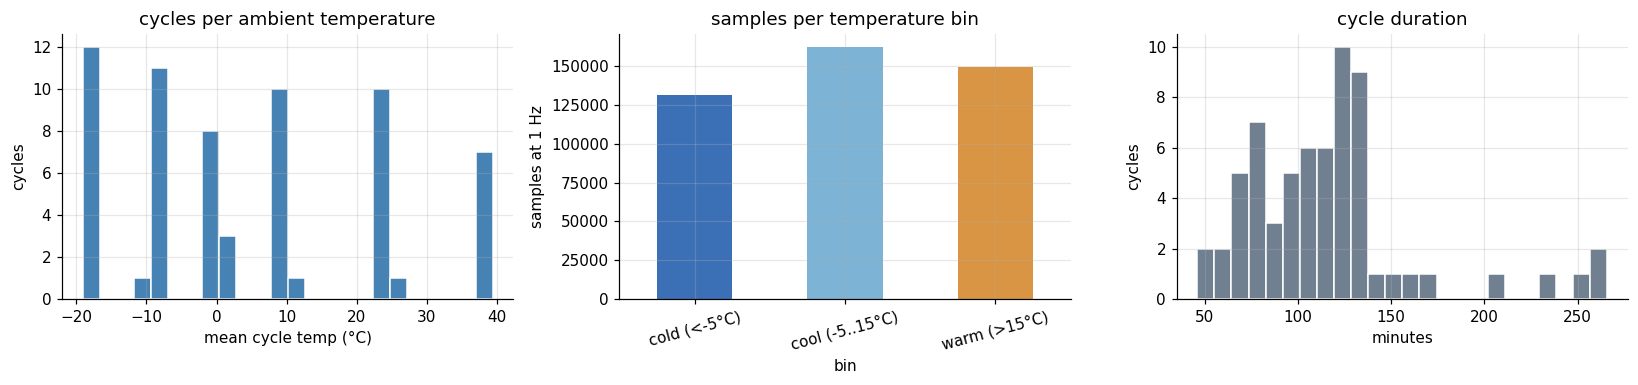

                 cycles  hours
bin                           
cold (<-5°C)         24   36.5
cool (-5..15°C)      22   45.1
warm (>15°C)         18   41.6


In [5]:
# ---- 4.1 · catalogue and temperature coverage --------------------------
cat = pd.DataFrame([dict(cycle=n, samples=len(d),
                         minutes=len(d) / 60 / CFG['target_hz'],
                         temp=d.Temperature.mean(),
                         ah_span=d.Capacity.max() - d.Capacity.min())
                    for n, d in cycles])
display(cat.sort_values('temp').head(8).round(2))

TEMP_EDGES = [-100, -5, 15, 100]                       # cold / cool / warm
BIN_NAMES  = ['cold (<-5°C)', 'cool (-5..15°C)', 'warm (>15°C)']
cat['bin'] = pd.cut(cat.temp, TEMP_EDGES, labels=BIN_NAMES)

fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
ax[0].hist(cat.temp, bins=24, color='steelblue', edgecolor='w')
ax[0].set(title='cycles per ambient temperature', xlabel='mean cycle temp (°C)',
          ylabel='cycles')
cat.groupby('bin').samples.sum().plot.bar(ax=ax[1], rot=15,
                                          color=['#3b6fb6', '#7db3d5', '#d99543'])
ax[1].set(title='samples per temperature bin', ylabel='samples at 1 Hz')
ax[2].hist(cat.minutes, bins=24, color='slategray', edgecolor='w')
ax[2].set(title='cycle duration', xlabel='minutes', ylabel='cycles')
plt.tight_layout(); plt.show()

print(cat.groupby('bin').agg(cycles=('cycle', 'count'),
                             hours=('minutes', lambda m: m.sum() / 60)).round(1))

### 4.2 · A single drive cycle in detail

The plot below shows one complete discharge under a dynamic automotive load. Current
swings hard and fast, briefly going positive where the profile includes regenerative
braking. Voltage sags under load and relaxes during rests. Temperature drifts upward
as the cell self-heats. Throughout, SoC falls almost monotonically.

This is the estimation problem in one figure: recover the smooth hidden state in the
bottom panel from the three noisy, fast-moving observables above it.

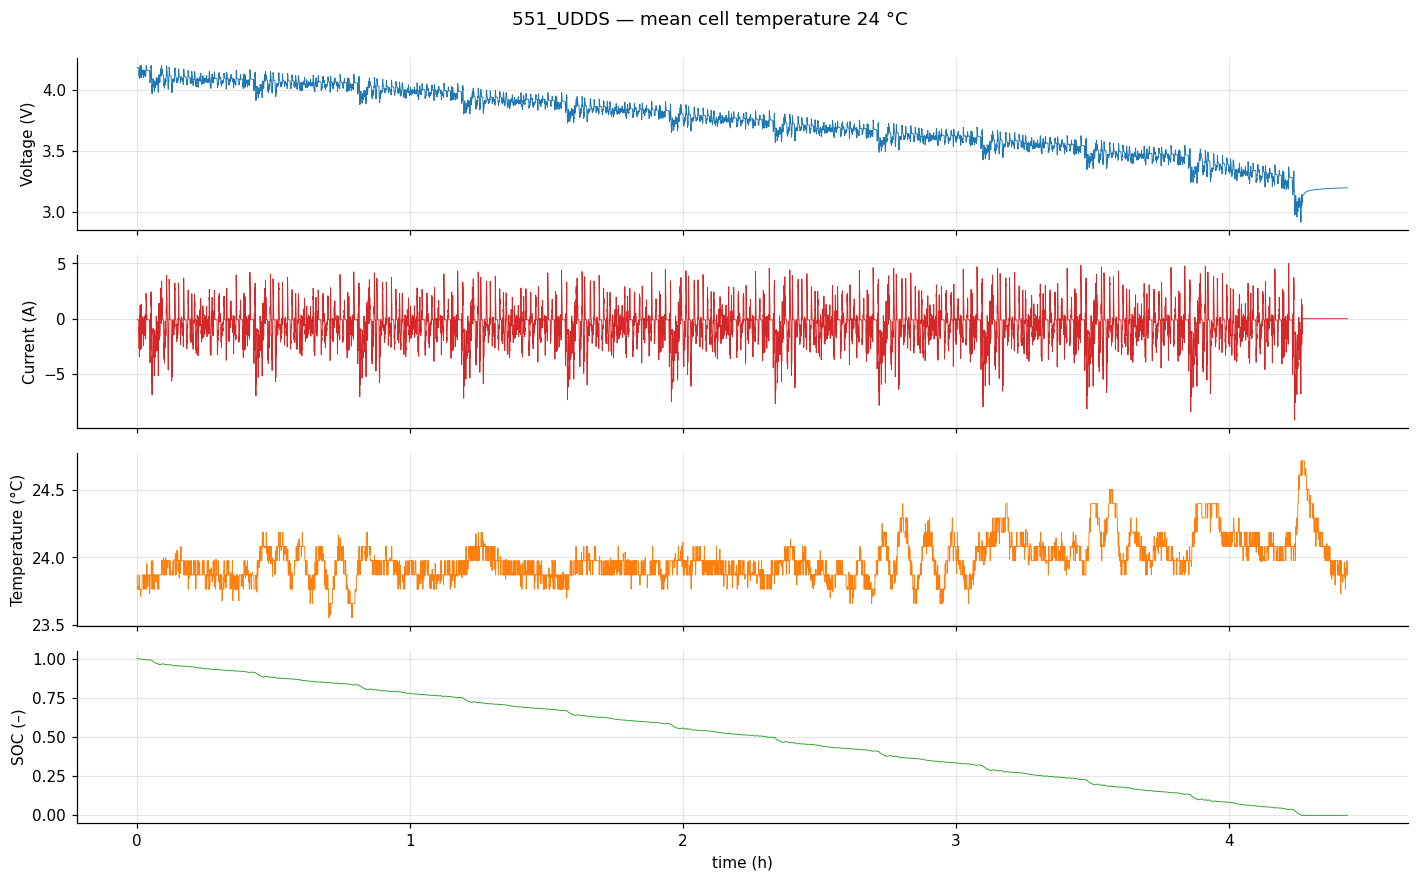

In [6]:
# ---- 4.2 · anatomy of one cycle ----------------------------------------
warm_idx = [i for i, (n, d) in enumerate(cycles) if 18 < d.Temperature.mean() < 32]
show = max(warm_idx or range(len(cycles)), key=lambda i: len(cycles[i][1]))
name, d = cycles[show]
t = np.arange(len(d)) / 3600.0

fig, ax = plt.subplots(4, 1, figsize=(13, 8), sharex=True)
for a, col, c, unit in zip(ax, ['Voltage', 'Current', 'Temperature', 'SOC'],
                           ['#1f77b4', '#d62728', '#ff7f0e', '#2ca02c'],
                           ['V', 'A', '°C', '–']):
    a.plot(t, d[col], c, lw=.6)
    a.set_ylabel(f'{col} ({unit})')
ax[-1].set_xlabel('time (h)')
fig.suptitle(f'{name} — mean cell temperature {d.Temperature.mean():.0f} °C', y=.995)
plt.tight_layout(); plt.show()

### 4.3 · The physics the estimator exploits

The left panel overlays the SoC trajectory of every retained cycle, coloured by mean
temperature. Cold cycles terminate sooner because less capacity is available, and
their trajectories are visibly less smooth.

The right panel is the more important one. Plotting terminal voltage against SoC shows
the relationship **fanning out with temperature**: at −20 °C the internal resistance
rises sharply, so the same SoC presents a substantially lower loaded voltage. There is
therefore no single voltage-to-SoC mapping — the mapping is itself a function of
temperature and load history.

This is precisely the nonlinearity that motivates deep sequence models over lookup
tables or fixed equivalent-circuit models, and it is the reason every serious study of
this problem trains and tests across the full temperature range rather than at 25 °C
alone.

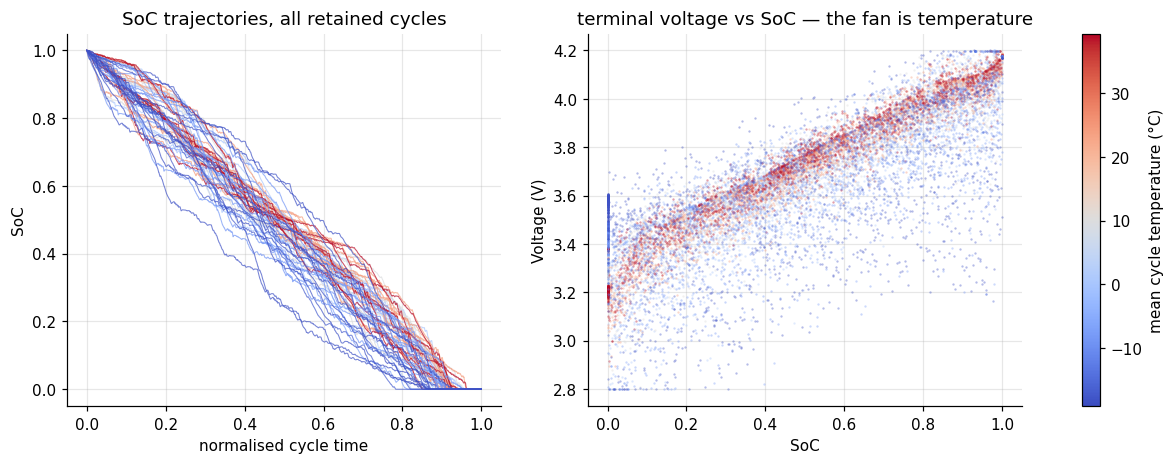

In [7]:
# ---- 4.3 · SoC trajectories and the voltage-SoC fan --------------------
import matplotlib.cm as cm
from matplotlib.colors import Normalize
norm = Normalize(cat.temp.min(), cat.temp.max())

fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
for n, dc in cycles:
    c = cm.coolwarm(norm(dc.Temperature.mean()))
    ax[0].plot(np.linspace(0, 1, len(dc)), dc.SOC, color=c, lw=.7, alpha=.7)
    ax[1].plot(dc.SOC[::30], dc.Voltage[::30], '.', color=c, ms=1, alpha=.4)
ax[0].set(title='SoC trajectories, all retained cycles',
          xlabel='normalised cycle time', ylabel='SoC')
ax[1].set(title='terminal voltage vs SoC — the fan is temperature',
          xlabel='SoC', ylabel='Voltage (V)')
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='coolwarm'), ax=ax,
             label='mean cycle temperature (°C)')
plt.show()

### 4.4 · Distributions and feature correlation

The histograms show the marginal distribution of each measured channel. Current is
plotted on a logarithmic count axis because the drive cycles spend most of their time
near moderate loads with a long tail of hard transients — the same spikiness that
motivates the block-averaged resampling used in Section 3.

The correlation matrix justifies the engineered features. Raw terminal voltage is
correlated with SoC but is corrupted by the instantaneous load, whereas the rolling
means integrate the load transients out and correlate far more cleanly. In effect
`V_avg` acts as a cheap, strictly causal proxy for open-circuit voltage, and `I_avg`
summarises the recent C-rate. Providing both a 60 s and a 300 s window lets the network
separate short-term load context from the slower electrochemical state.

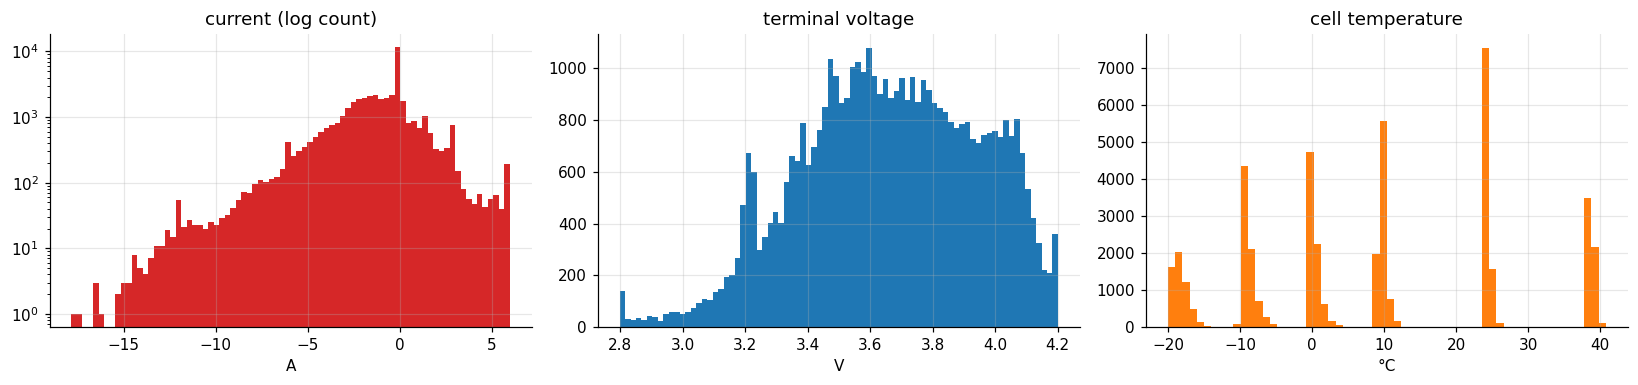

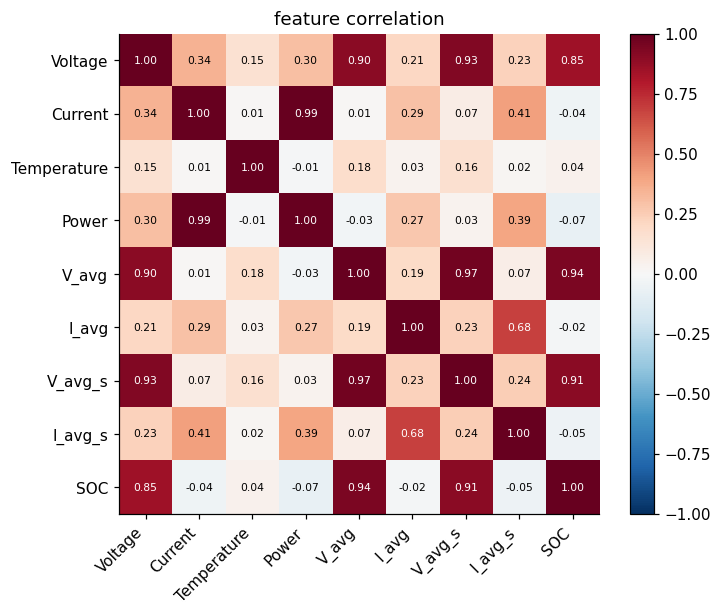

correlation with SoC, ranked:
V_avg          0.938
V_avg_s        0.906
Voltage        0.850
Power         -0.072
I_avg_s       -0.054
Temperature    0.043
Current       -0.040
I_avg         -0.018


In [8]:
# ---- 4.4 · distributions and correlation -------------------------------
allsub = pd.concat([dc.iloc[::10] for _, dc in cycles], ignore_index=True)

fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
ax[0].hist(allsub.Current, bins=80, color='#d62728'); ax[0].set_yscale('log')
ax[0].set(title='current (log count)', xlabel='A')
ax[1].hist(allsub.Voltage, bins=80, color='#1f77b4')
ax[1].set(title='terminal voltage', xlabel='V')
ax[2].hist(allsub.Temperature, bins=60, color='#ff7f0e')
ax[2].set(title='cell temperature', xlabel='°C')
plt.tight_layout(); plt.show()

corr = allsub[FEATURES + ['SOC']].corr()
fig, ax = plt.subplots(figsize=(6.8, 5.6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                color='w' if abs(corr.iloc[i, j]) > .6 else 'k', fontsize=7)
ax.grid(False); ax.set_title('feature correlation')
fig.colorbar(im); plt.tight_layout(); plt.show()

print('correlation with SoC, ranked:')
print(corr['SOC'].drop('SOC').sort_values(key=abs, ascending=False).round(3).to_string())

## 5 · Windowing and dataset splits

### Sliding-window formulation

Each training sample is a 100-step (100 s) history of the eight features, and the
label is the SoC at the final step of that window. This is the formulation introduced
for this problem by Chemali et al. (2018) and used by essentially all subsequent work.

### Two rules that determine whether the reported accuracy is real

**Split by whole drive cycle, never by window.** Consecutive windows overlap by 99 of
their 100 samples, so a randomly partitioned window split places near-duplicates in
both the training and test sets. The resulting error is not an estimate of
generalisation at all; it is an estimate of memorisation, and it is optimistic by a
large margin. Splitting at the level of complete cycles removes this entirely.

**Stratify the split by temperature.** Cycles are sorted by mean temperature and dealt
round-robin into the three partitions, so that training, validation and test each span
the full −20 °C to +40 °C range. A naive random split over cycles can otherwise assign
an entire temperature regime to the test set, producing a pessimistic and unstable
result that reflects extrapolation rather than estimation quality.

### Scaling

Standardisation statistics are computed on the **training partition only** and then
applied unchanged to validation and test. Fitting the scaler over the pooled dataset
is a small but genuine form of leakage, since test-set statistics would influence the
representation the model sees during training.

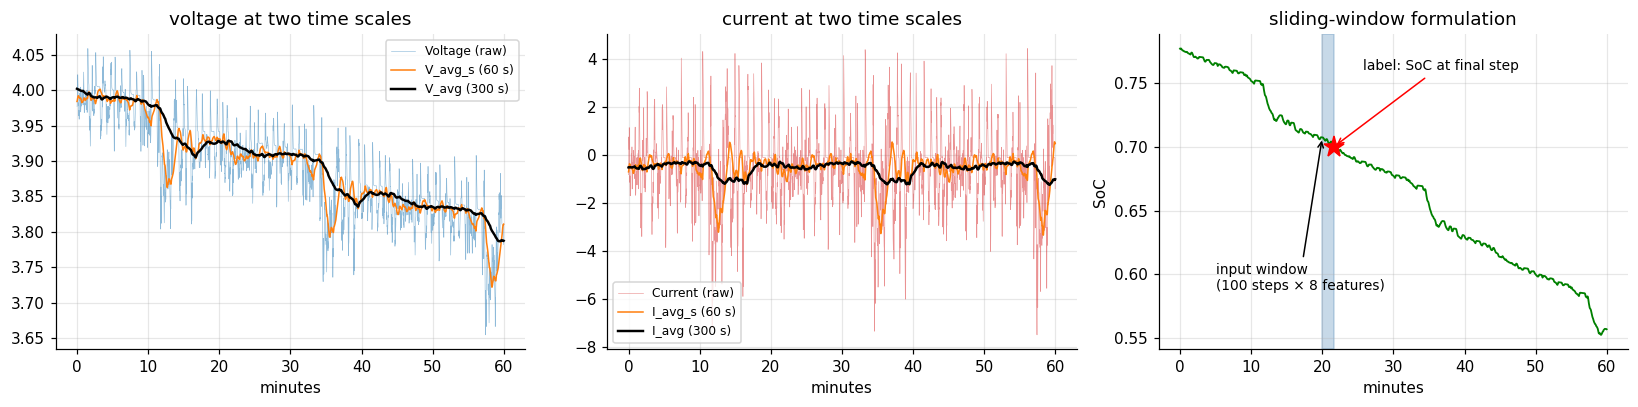

In [9]:
# ---- 5.1 · what the rolling features add, and the window schematic -----
name, d = cycles[show]
lo = min(3600, max(0, len(d) - 3600))
z = d.iloc[lo:lo + 3600]
tz = np.arange(len(z)) / 60.0

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].plot(tz, z.Voltage, lw=.4, alpha=.5, label='Voltage (raw)')
ax[0].plot(tz, z.V_avg_s, lw=1.0, color='#ff7f0e', label='V_avg_s (60 s)')
ax[0].plot(tz, z.V_avg, 'k', lw=1.6, label='V_avg (300 s)')
ax[0].set(title='voltage at two time scales', xlabel='minutes'); ax[0].legend(fontsize=8)

ax[1].plot(tz, z.Current, lw=.4, alpha=.5, color='#d62728', label='Current (raw)')
ax[1].plot(tz, z.I_avg_s, lw=1.0, color='#ff7f0e', label='I_avg_s (60 s)')
ax[1].plot(tz, z.I_avg, 'k', lw=1.6, label='I_avg (300 s)')
ax[1].set(title='current at two time scales', xlabel='minutes'); ax[1].legend(fontsize=8)

s0 = min(1200, len(z) - CFG['seq_len'] - 1)
ax[2].plot(tz, z.SOC, 'g', lw=1.2)
ax[2].axvspan(tz[s0], tz[s0 + CFG['seq_len']], color='steelblue', alpha=.3)
ax[2].plot(tz[s0 + CFG['seq_len']], z.SOC.iloc[s0 + CFG['seq_len']], 'r*', ms=14)
ax[2].annotate('input window\n(100 steps × 8 features)', (tz[s0], z.SOC.iloc[s0]),
               xytext=(tz[s0] - 15, z.SOC.iloc[s0] - .12), fontsize=9,
               arrowprops=dict(arrowstyle='->'))
ax[2].annotate('label: SoC at final step',
               (tz[s0 + CFG['seq_len']], z.SOC.iloc[s0 + CFG['seq_len']]),
               xytext=(tz[s0 + CFG['seq_len']] + 4, z.SOC.iloc[s0 + CFG['seq_len']] + .06),
               fontsize=9, arrowprops=dict(arrowstyle='->', color='r'))
ax[2].set(title='sliding-window formulation', xlabel='minutes', ylabel='SoC')
plt.tight_layout(); plt.show()

443,390 samples -> stride 2
  train   38 cycles  temperatures [-18, -18, -18, -18, -18, -18, -10, -9, -9, -9, -9, -9, -9, -7, 0, 0, 0, 0, 0, 0, 2, 10, 10, 10, 10, 10, 10, 24, 24, 24, 24, 24, 24, 39, 39, 39, 39, 39]
  val     13 cycles  temperatures [-18, -18, -17, -9, -9, 0, 0, 10, 10, 24, 24, 25, 39]
  test    13 cycles  temperatures [-19, -18, -18, -9, -9, 0, 0, 9, 10, 11, 24, 24, 39]

  train   130,611 windows  shape (100, 8)
  val      43,842 windows  shape (100, 8)
  test     44,091 windows  shape (100, 8)


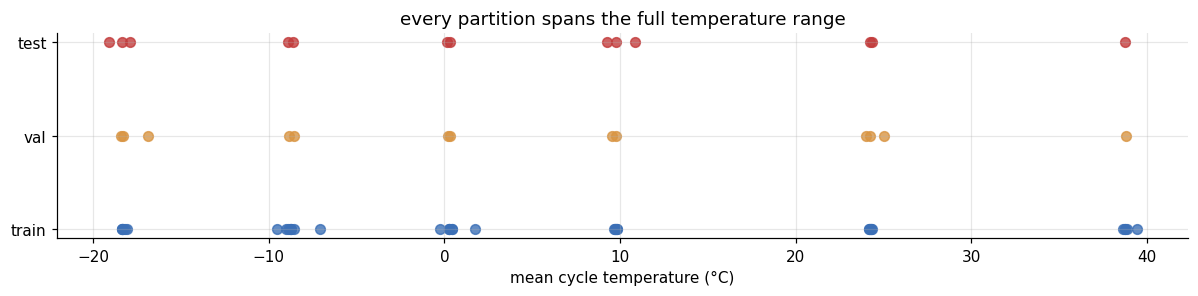

In [10]:
# ---- 5.2 · build windows and the temperature-stratified split ----------
def make_windows(df, stride=None):
    """Slice a cycle into overlapping (100, n_features) windows labelled by final SoC."""
    L = CFG['seq_len']
    stride = stride or CFG['stride']
    F = df[FEATURES].to_numpy(np.float32)
    y = df['SOC'].to_numpy(np.float32)
    idx = np.arange(L - 1, len(df), stride)
    return np.stack([F[i - L + 1:i + 1] for i in idx]), y[idx]

# A stride of one over the full benchmark would materialise several million windows;
# the stride is therefore set from the dataset size to bound memory.
total = sum(len(d) for _, d in cycles)
CFG['stride'] = max(1, total // 200_000)
print(f'{total:,} samples -> stride {CFG["stride"]}')

order = sorted(range(len(cycles)), key=lambda i: cycles[i][1].Temperature.mean())
groups = {'train': [], 'val': [], 'test': []}
for rank, i in enumerate(order):
    groups['test' if rank % 5 == 0 else 'val' if rank % 5 == 1 else 'train'].append(i)

parts = {k: [make_windows(cycles[i][1]) for i in v] for k, v in groups.items()}
Xtr, ytr = (np.concatenate(z) for z in zip(*parts['train']))
Xva, yva = (np.concatenate(z) for z in zip(*parts['val']))
Xte, yte = (np.concatenate(z) for z in zip(*parts['test']))

# per-window test temperature, used for the error breakdown in section 8
Tte = np.concatenate([np.full(len(parts['test'][j][1]), cycles[i][1].Temperature.mean())
                      for j, i in enumerate(groups['test'])])

mu = Xtr.reshape(-1, len(FEATURES)).mean(0)              # training statistics only
sd = Xtr.reshape(-1, len(FEATURES)).std(0) + 1e-8
Xtr, Xva, Xte = ((X - mu) / sd for X in (Xtr, Xva, Xte))

for k, v in groups.items():
    temps = sorted(round(cycles[i][1].Temperature.mean()) for i in v)
    print(f'  {k:<6} {len(v):>3} cycles  temperatures {temps}')
print()
for nm, X in [('train', Xtr), ('val', Xva), ('test', Xte)]:
    print(f'  {nm:<6} {X.shape[0]:>8,} windows  shape {X.shape[1:]}')

fig, ax = plt.subplots(figsize=(11, 2.8))
for k, c in zip(('train', 'val', 'test'), ('#3b6fb6', '#d99543', '#c23b3b')):
    temps = [cycles[i][1].Temperature.mean() for i in groups[k]]
    ax.scatter(temps, [k] * len(temps), color=c, s=40, alpha=.8)
ax.set(title='every partition spans the full temperature range',
       xlabel='mean cycle temperature (°C)')
plt.tight_layout(); plt.show()

### 5.3 · No cycle appears in more than one split

The split is disjoint by construction — every cycle index is dealt into exactly one of the
three groups — but "by construction" is an argument, not evidence, and the accuracy figures
in section 8 are only worth reading if it holds. This cell checks it three ways: that the
index sets are disjoint and complete, that no test file was loaded twice under two names,
and that no two cycles in different splits are near-duplicates of the same physical test.

The third check is the one that matters. A duplicated export sitting in both train and test
would leak the answer without ever violating the cycle-level rule.

In [ ]:
# ---- 5.3 · leakage check: is any cycle in more than one split? ---------
idx = {k: set(v) for k, v in groups.items()}

# 1 · the index sets partition the catalogue
for a, b in [('train', 'val'), ('train', 'test'), ('val', 'test')]:
    shared = idx[a] & idx[b]
    assert not shared, f'{a}/{b} share cycles {[cycles[i][0] for i in shared]}'
assert set().union(*idx.values()) == set(range(len(cycles))), 'a cycle is unassigned'
assert sum(map(len, idx.values())) == len(cycles), 'counts do not add up'
print(f'1 · index sets disjoint and complete  '
      f'({len(idx["train"])}+{len(idx["val"])}+{len(idx["test"])} = {len(cycles)} cycles)')

# 2 · no file loaded twice under two names
names = [n for n, _ in cycles]
assert len(set(names)) == len(names), 'duplicate file stems in the catalogue'
print(f'2 · {len(set(names))} distinct source files, no repeats')

# 3 · no near-duplicate test across splits
def profile(d, n=256):
    """Length-normalised voltage and current signature of a cycle."""
    t = np.linspace(0, 1, n)
    s = np.linspace(0, 1, len(d))
    v = np.interp(t, s, d.Voltage.to_numpy(np.float64))
    i = np.interp(t, s, d.Current.to_numpy(np.float64))
    return np.concatenate([(v - v.mean()) / (v.std() + 1e-9),
                           (i - i.mean()) / (i.std() + 1e-9)])

P = np.stack([profile(d) for _, d in cycles])
D = np.sqrt(((P[:, None, :] - P[None, :, :]) ** 2).mean(-1))
np.fill_diagonal(D, np.inf)

split_of = {i: k for k, v in groups.items() for i in v}
cross = np.array([[split_of[a] != split_of[b] for b in range(len(cycles))]
                  for a in range(len(cycles))])

a, b = np.unravel_index(np.argmin(np.where(cross, D, np.inf)), D.shape)
c, e = np.unravel_index(np.argmin(np.where(cross, np.inf, D)), D.shape)
print(f'3 · closest pair across splits   {D[a, b]:.3f}   '
      f'{cycles[a][0]} ({split_of[a]}) vs {cycles[b][0]} ({split_of[b]})')
print(f'    closest pair within a split  {D[c, e]:.3f}   '
      f'{cycles[c][0]} vs {cycles[e][0]}')
print(f'    median distance over all pairs {np.median(D[np.isfinite(D)]):.3f}')

DUP = 0.05
assert D[a, b] > DUP, 'a near-identical cycle sits on both sides of the split'
print(f'\nno cycle, and no duplicate of a cycle, appears in more than one split')


## 6 · Model architectures

Six estimators are compared. The first five are reimplementations of published
designs, which establish the baseline; the sixth is a hybrid proposed here that
combines the components which each of those papers found beneficial.

| Model | Source | Core idea |
|---|---|---|
| Ridge | Mitikiri et al. (2024) | linear regression on the flattened window — the floor a deep model must beat |
| FNN | Vidal et al. (2020) | feed-forward network on the final timestep plus rolling averages |
| CNN-LSTM | Song et al. (2019) | 1-D convolutions extract local waveform features, an LSTM tracks them through time |
| Bi-LSTM + attention | Mamo & Wang (2020); Li et al. (2026) | bidirectional recurrence with attention pooling over timesteps |
| LSTM multi-task | Ma et al. (2025) | LSTM with two heads: SoC and voltage reconstruction |
| **Proposed hybrid** | this work | all four components combined (see below) |

### The proposed hybrid

Each reviewed architecture contributes one component that its authors showed to be
useful in isolation, and there is no published evaluation of all four together on this
cell. The hybrid stacks them:

1. **Convolutional front-end** (Song et al., 2019) — two 1-D convolutions extract local
   waveform structure, such as the shape of a load transient, before any recurrence.
2. **Bidirectional LSTM** (Terala et al., 2022) — within a completed 100 s window the
   future of the window is available, so both directions can be exploited; a
   bidirectional pass lets the representation of an early timestep be informed by what
   followed it.
3. **Attention pooling** (Mamo & Wang, 2020; Li et al., 2026) — rather than taking only
   the final hidden state, an additive attention layer learns which timesteps in the
   window carry the most information about SoC. Rest periods, where voltage relaxes
   toward open circuit, are far more informative than moments of hard load, and
   attention allows the network to weight them accordingly.
4. **Multi-task reconstruction head** (Ma et al., 2025) — a second output reconstructs
   the voltage sequence. This regularises the shared encoder by forcing it to retain
   physically meaningful information, and its error provides an intrinsic confidence
   signal.

**This design is a hypothesis, not a result.** Combining components that each help in
isolation does not guarantee an improvement: the hybrid carries more parameters, and
additional capacity on a dataset of this size can as easily overfit as help. Section 7
therefore trains every architecture three times from different random initialisations
and compares them on the spread of those runs, not on a single number. Vidal et al.
(2020) show explicitly that run-to-run variation on this problem can exceed the gap
between two architectures, so a single training run cannot settle the question.

In [11]:
# ---- model definitions -------------------------------------------------
NF = len(FEATURES)

class FNN(nn.Module):
    """Feed-forward baseline: dense network on the final timestep."""
    def __init__(self, nf=NF, h=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(nf, h), nn.ReLU(),
                                 nn.Linear(h, h), nn.ReLU(),
                                 nn.Linear(h, h // 2), nn.ReLU(),
                                 nn.Linear(h // 2, 1), nn.Sigmoid())
    def forward(self, x):
        return self.net(x[:, -1, :]).squeeze(-1)

class CNNLSTM(nn.Module):
    """Convolutional front-end for local features, LSTM for temporal state."""
    def __init__(self, nf=NF, h=None):
        super().__init__()
        h = h or CFG['hidden']
        self.conv = nn.Sequential(nn.Conv1d(nf, 64, 5, padding=2), nn.ReLU(),
                                  nn.Conv1d(64, 64, 3, padding=1), nn.ReLU())
        self.lstm = nn.LSTM(64, h, batch_first=True)
        self.head = nn.Sequential(nn.Linear(h, 64), nn.ReLU(),
                                  nn.Linear(64, 1), nn.Sigmoid())
    def forward(self, x):
        z = self.conv(x.transpose(1, 2)).transpose(1, 2)
        out, _ = self.lstm(z)
        return self.head(out[:, -1]).squeeze(-1)

class BiLSTMAttn(nn.Module):
    """Bidirectional LSTM with additive attention pooling over timesteps."""
    def __init__(self, nf=NF, h=None):
        super().__init__()
        h = h or CFG['hidden']
        self.lstm = nn.LSTM(nf, h, batch_first=True, bidirectional=True)
        self.att  = nn.Linear(2 * h, 1)
        self.head = nn.Sequential(nn.Linear(2 * h, 64), nn.ReLU(),
                                  nn.Linear(64, 1), nn.Sigmoid())
    def forward(self, x):
        out, _ = self.lstm(x)
        a = torch.softmax(self.att(out).squeeze(-1), dim=1)
        ctx = (out * a.unsqueeze(-1)).sum(1)
        return self.head(ctx).squeeze(-1)

class LSTMMultiTask(nn.Module):
    """Shared LSTM encoder with an SoC head and a voltage-reconstruction head.

    The reconstruction error doubles as an intrinsic confidence signal: when the input
    stops resembling the physics the encoder was trained on, that error rises.
    """
    def __init__(self, nf=NF, h=None):
        super().__init__()
        h = h or CFG['hidden']
        self.lstm  = nn.LSTM(nf, h, batch_first=True)
        self.soc   = nn.Sequential(nn.Linear(h, 64), nn.ReLU(),
                                   nn.Linear(64, 1), nn.Sigmoid())
        self.recon = nn.Linear(h, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.soc(out[:, -1]).squeeze(-1), self.recon(out).squeeze(-1)

class HybridSOC(nn.Module):
    """Proposed hybrid: convolutional front-end, bidirectional recurrence,
    attention pooling, and a multi-task reconstruction head.

    The convolutions are zero-padded so the sequence length is preserved, which keeps
    the attention weights and the reconstruction output aligned with the input
    timesteps. The hidden size is reduced relative to the single-direction models so
    that the bidirectional pass does not inflate the parameter count beyond the range
    of the architectures it is compared against.
    """
    def __init__(self, nf=NF, h=None):
        super().__init__()
        h = h or CFG['hidden'] // 2                      # bidirectional doubles width
        self.conv = nn.Sequential(nn.Conv1d(nf, 64, 5, padding=2), nn.ReLU(),
                                  nn.Conv1d(64, 64, 3, padding=1), nn.ReLU())
        self.lstm  = nn.LSTM(64, h, batch_first=True, bidirectional=True)
        self.att   = nn.Linear(2 * h, 1)
        self.soc   = nn.Sequential(nn.Linear(2 * h, 64), nn.ReLU(),
                                   nn.Linear(64, 1), nn.Sigmoid())
        self.recon = nn.Linear(2 * h, 1)
    def forward(self, x):
        z = self.conv(x.transpose(1, 2)).transpose(1, 2)
        out, _ = self.lstm(z)
        a = torch.softmax(self.att(out).squeeze(-1), dim=1)
        ctx = (out * a.unsqueeze(-1)).sum(1)
        return self.soc(ctx).squeeze(-1), self.recon(out).squeeze(-1)

# Multi-task models return a tuple; the rest return a tensor.
ARCHITECTURES = [('FNN',         FNN,           False),
                 ('CNN-LSTM',    CNNLSTM,       False),
                 ('BiLSTM-Attn', BiLSTMAttn,    False),
                 ('LSTM-MT',     LSTMMultiTask, True),
                 ('Hybrid',      HybridSOC,     True)]

print(f'{"architecture":<14}{"parameters":>12}   output')
for tag, cls, mt in ARCHITECTURES:
    m = cls()
    n = sum(p.numel() for p in m.parameters())
    with torch.no_grad():                                # shape check on a dummy batch
        o = m(torch.zeros(4, CFG['seq_len'], NF))
    shapes = tuple(t.shape for t in o) if isinstance(o, tuple) else (o.shape,)
    print(f'{tag:<14}{n:>12,}   {shapes}')
    assert (o[0] if mt else o).shape == (4,), f'{tag}: unexpected SoC head shape'
print('\nall architectures instantiate and produce correctly shaped output')

architecture    parameters   output
FNN                 25,985   (torch.Size([4]),)
CNN-LSTM           122,625   (torch.Size([4]),)
BiLSTM-Attn        158,082   (torch.Size([4]),)
LSTM-MT             79,106   (torch.Size([4]), torch.Size([4, 100]))
Hybrid              90,115   (torch.Size([4]), torch.Size([4, 100]))

all architectures instantiate and produce correctly shaped output


### 6.1 · Training procedure

A single training routine is used for every architecture so that no model benefits
from a better-tuned optimiser than another: Adam, cosine learning-rate decay, gradient
clipping at unit norm, and mixed precision when a GPU is present.

Early stopping monitors **validation** mean absolute error and restores the best
observed weights. The test partition is never consulted during training or model
selection; it is read exactly once, after the final architecture has been chosen.

The two multi-task models add a voltage-reconstruction term to the loss with weight
0.1. This value is deliberately small: the reconstruction task exists to regularise
the shared encoder and to provide a confidence signal, not to compete with the SoC
objective.

In [12]:
# ---- training utilities ------------------------------------------------
from torch.utils.data import TensorDataset, DataLoader

V_IDX, RECON_W = FEATURES.index('Voltage'), 0.1

def make_loader(X, y, shuffle):
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(ds, batch_size=CFG['batch_size'], shuffle=shuffle,
                      num_workers=2, pin_memory=(DEV.type == 'cuda'))

dl_tr = make_loader(Xtr, ytr, True)

def predict(model, X, bs=1024):
    """SoC prediction for an already-scaled window array; handles both head types."""
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(X), bs):
            xb = torch.from_numpy(X[i:i + bs]).to(DEV)
            o = model(xb)
            out.append((o[0] if isinstance(o, tuple) else o).float().cpu().numpy())
    return np.concatenate(out)

def metrics(pred, true):
    """Errors expressed in percentage points of SoC."""
    e = (pred - true) * 100.0
    ss = ((true - true.mean()) ** 2).sum()
    return dict(MAE=np.abs(e).mean(), RMSE=np.sqrt((e ** 2).mean()),
                MaxErr=np.abs(e).max(),
                R2=1 - ((pred - true) ** 2).sum() / ss if ss > 0 else float('nan'))

def train(model, tag, multitask=False, epochs=None, verbose=True):
    epochs = epochs or CFG['epochs']
    model  = model.to(DEV)
    opt    = torch.optim.Adam(model.parameters(), lr=CFG['lr'])
    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    scaler = torch.amp.GradScaler('cuda', enabled=(DEV.type == 'cuda'))
    mse = nn.MSELoss()

    best, best_state, bad, hist = float('inf'), None, 0, []
    t0 = time.time()
    for ep in range(1, epochs + 1):
        model.train()
        for xb, yb in dl_tr:
            xb, yb = xb.to(DEV, non_blocking=True), yb.to(DEV, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=(DEV.type == 'cuda')):
                if multitask:
                    p, rec = model(xb)
                    loss = mse(p, yb) + RECON_W * mse(rec, xb[:, :, V_IDX])
                else:
                    loss = mse(model(xb), yb)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update()
        sched.step()

        vmae = metrics(predict(model, Xva), yva)['MAE']
        hist.append(vmae)
        if vmae < best - 1e-4:
            best, bad = vmae, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
        if verbose and (ep % 10 == 0 or ep == 1):
            print(f'      epoch {ep:>3}  val MAE {vmae:.3f}  (best {best:.3f})')
        if bad >= CFG['patience']:
            break

    if best_state:
        model.load_state_dict(best_state)
    return model, hist, best, time.time() - t0

print('training utilities ready')

training utilities ready


## 7 · Training and repeated-run comparison

### Why every architecture is trained three times

A neural network's final error depends on its random initialisation. Vidal et al.
(2020) train the same two architectures fifty times each on this problem and show
that the spread across repetitions can be larger than the difference between the two
architectures — so a comparison based on one run per model measures initialisation
luck as much as design.

Each architecture is therefore trained three times from different seeds, and results
are reported as **mean ± standard deviation** across those runs. An architecture is
only described as better than another when the gap between their means is large
relative to that spread. Three repetitions is a compromise with the available compute
budget; it is enough to expose whether a difference is robust, though not enough for a
formal significance test.

The ridge baseline is fitted once, as it has a closed-form solution and no random
initialisation.

> This cell performs the bulk of the computation — five architectures × three seeds.
> A GPU runtime is required; on a T4 it takes roughly 30–45 minutes.

In [13]:
# ---- train every architecture across multiple seeds --------------------
from sklearn.linear_model import Ridge

if DEV.type != 'cuda':
    print('WARNING: no GPU detected — this cell will be extremely slow on CPU.\n'
          '         Runtime > Change runtime type > T4 GPU, then re-run from the top.\n')

SEED_LIST = [CFG['seed'] + k for k in range(CFG['n_seeds'])]
runs = []            # one record per (architecture, seed)
MODELS = {}          # best model per architecture, kept for the analysis below
HIST = {}

# --- ridge baseline: deterministic, fitted once -------------------------
t0 = time.time()
ridge = Ridge(alpha=1.0).fit(Xtr.reshape(len(Xtr), -1), ytr)
p_te = np.clip(ridge.predict(Xte.reshape(len(Xte), -1)), 0, 1).astype(np.float32)
p_va = np.clip(ridge.predict(Xva.reshape(len(Xva), -1)), 0, 1).astype(np.float32)
m_te, m_va = metrics(p_te, yte), metrics(p_va, yva)
runs.append(dict(model='Ridge', seed=0, val_MAE=m_va['MAE'], secs=time.time() - t0,
                 **{k: v for k, v in m_te.items()}))
print(f'Ridge            val MAE {m_va["MAE"]:.3f}   test MAE {m_te["MAE"]:.3f}'
      f'   ({time.time()-t0:.0f}s)')

# --- deep architectures -------------------------------------------------
for tag, cls, mt in ARCHITECTURES:
    print(f'\n{tag}')
    best_val_for_tag = float('inf')
    for seed in SEED_LIST:
        set_seed(seed)
        model, hist, vbest, secs = train(cls(), tag, multitask=mt, verbose=False)
        te = metrics(predict(model, Xte), yte)
        runs.append(dict(model=tag, seed=seed, val_MAE=vbest, secs=secs, **te))
        print(f'   seed {seed}   val MAE {vbest:.3f}   test MAE {te["MAE"]:.3f}'
              f'   RMSE {te["RMSE"]:.3f}   ({secs:.0f}s, {len(hist)} epochs)')
        if vbest < best_val_for_tag:                 # keep the best run of this design
            best_val_for_tag = vbest
            MODELS[tag], HIST[tag] = model, hist

runs = pd.DataFrame(runs)
runs.to_csv('training_runs.csv', index=False)        # guard against a lost runtime
print(f'\ncompleted {len(runs)} runs, {runs.secs.sum()/60:.1f} min total')

Ridge            val MAE 3.981   test MAE 4.591   (29s)

FNN
   seed 42   val MAE 0.898   test MAE 1.139   RMSE 1.963   (116s, 35 epochs)
   seed 43   val MAE 0.923   test MAE 1.147   RMSE 1.967   (86s, 26 epochs)
   seed 44   val MAE 0.901   test MAE 1.123   RMSE 1.904   (133s, 40 epochs)

CNN-LSTM
   seed 42   val MAE 0.740   test MAE 0.946   RMSE 1.599   (96s, 18 epochs)
   seed 43   val MAE 0.699   test MAE 0.979   RMSE 1.834   (121s, 23 epochs)
   seed 44   val MAE 0.743   test MAE 0.952   RMSE 1.649   (101s, 19 epochs)

BiLSTM-Attn
   seed 42   val MAE 0.608   test MAE 0.803   RMSE 1.380   (179s, 29 epochs)
   seed 43   val MAE 0.629   test MAE 0.821   RMSE 1.374   (190s, 31 epochs)
   seed 44   val MAE 0.608   test MAE 0.840   RMSE 1.400   (209s, 34 epochs)

LSTM-MT
   seed 42   val MAE 0.632   test MAE 0.850   RMSE 1.496   (134s, 27 epochs)
   seed 43   val MAE 0.604   test MAE 0.800   RMSE 1.267   (142s, 28 epochs)
   seed 44   val MAE 0.596   test MAE 0.792   RMSE 1.212   (17

## 8 · SoC estimation results

Errors are reported in **percentage points of SoC**: an MAE of 0.8 means the estimate
is wrong by 0.8 % of full charge on average.

For context, published results on this cell and its close relatives report mean
absolute errors of roughly 0.43 % (Benallal et al., 2025), 0.62 % at 25 °C (Terala et
al., 2022) and 0.17–0.77 % across −20 to 0 °C (Li et al., 2026) — generally with
heavier hyperparameter tuning and, in some cases, separate models per temperature.
Reaching a comparable error with a single model, a leakage-free cycle-level split and
whole unseen test cycles places the estimator in the same range as the literature.

The table below reports the mean and standard deviation across the repeated runs. The
final column is the decisive one: **where the spread across seeds is comparable to the
gap between two architectures, those architectures should be treated as tied.**

,MAE,MAE_sd,RMSE,RMSE_sd,R2,MaxErr,val_MAE,n,secs
model,,,,,,,,,
LSTM-MT,0.814,0.032,1.325,0.150,0.998,11.552000,0.611,3,148.900
BiLSTM-Attn,0.821,0.019,1.385,0.014,0.998,12.087000,0.615,3,192.636
Hybrid,0.850,0.006,1.357,0.082,0.998,14.350000,0.670,3,168.711
CNN-LSTM,0.959,0.018,1.694,0.124,0.997,22.330999,0.727,3,106.231
FNN,1.136,0.012,1.945,0.035,0.996,20.226999,0.907,3,111.949
Ridge,4.591,0.000,7.149,0.000,0.945,38.551998,3.981,1,28.708


test MAE across seeds (percentage points of SoC):
  LSTM-MT        0.814 ±0.026    runs: [0.85  0.8   0.792]
  BiLSTM-Attn    0.821 ±0.015    runs: [0.803 0.821 0.84 ]
  Hybrid         0.850 ±0.005    runs: [0.844 0.854 0.854]
  CNN-LSTM       0.959 ±0.014    runs: [0.946 0.979 0.952]
  FNN            1.136 ±0.010    runs: [1.139 1.147 1.123]
  Ridge          4.591   (single fit)    runs: [4.591]

leader: LSTM-MT (0.814) vs BiLSTM-Attn (0.821)
  gap 0.007 pp | pooled seed spread 0.026 pp | ratio 0.27
  VERDICT: TIED — the gap is within run-to-run variation, do not claim a winner


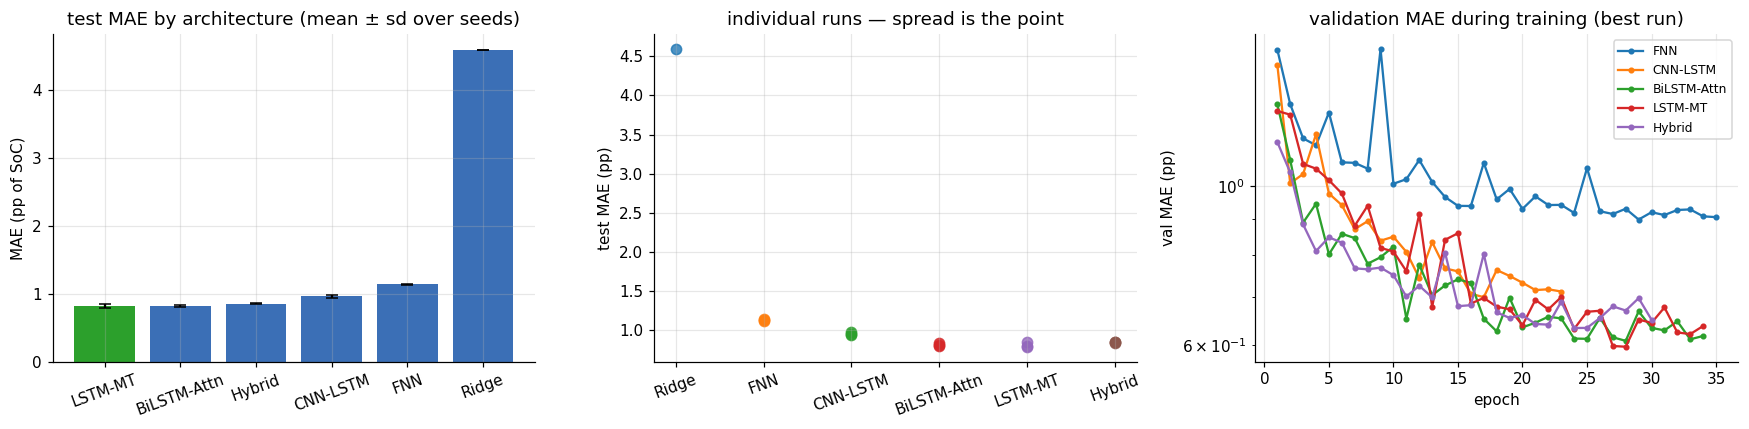


selected architecture: LSTM-MT (lowest mean validation MAE)


In [14]:
# ---- aggregate the repeated runs ---------------------------------------
agg = (runs.groupby('model')
           .agg(MAE=('MAE', 'mean'), MAE_sd=('MAE', 'std'),
                RMSE=('RMSE', 'mean'), RMSE_sd=('RMSE', 'std'),
                R2=('R2', 'mean'), MaxErr=('MaxErr', 'mean'),
                val_MAE=('val_MAE', 'mean'), n=('MAE', 'size'),
                secs=('secs', 'mean'))
           .fillna(0).sort_values('MAE'))
display(agg.round(3))

print('test MAE across seeds (percentage points of SoC):')
for m in agg.index:
    v = runs.loc[runs.model == m, 'MAE'].values
    spread = f'±{v.std():.3f}' if len(v) > 1 else '  (single fit)'
    print(f'  {m:<14} {v.mean():.3f} {spread}    runs: {np.round(v, 3)}')

# Is the leader actually ahead, or is the gap inside the noise?
deep = agg.drop(index='Ridge', errors='ignore')
if len(deep) >= 2:
    best, second = deep.index[0], deep.index[1]
    gap = deep.loc[second, 'MAE'] - deep.loc[best, 'MAE']
    pooled = np.sqrt((deep.loc[best, 'MAE_sd'] ** 2 + deep.loc[second, 'MAE_sd'] ** 2) / 2)
    print(f'\nleader: {best} ({deep.loc[best, "MAE"]:.3f}) vs '
          f'{second} ({deep.loc[second, "MAE"]:.3f})')
    print(f'  gap {gap:.3f} pp | pooled seed spread {pooled:.3f} pp | '
          f'ratio {gap / pooled if pooled else float("inf"):.2f}')
    print('  VERDICT:', 'separated — the gap exceeds run-to-run variation'
          if pooled and gap > 2 * pooled else
          'TIED — the gap is within run-to-run variation, do not claim a winner')

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].bar(agg.index, agg.MAE, yerr=agg.MAE_sd, capsize=4,
          color=['#2ca02c' if i == 0 else '#3b6fb6' for i in range(len(agg))])
ax[0].set(title='test MAE by architecture (mean ± sd over seeds)',
          ylabel='MAE (pp of SoC)')
ax[0].tick_params(axis='x', rotation=20)

for m in runs.model.unique():
    v = runs.loc[runs.model == m, 'MAE'].values
    ax[1].scatter([m] * len(v), v, s=45, alpha=.8)
ax[1].set(title='individual runs — spread is the point', ylabel='test MAE (pp)')
ax[1].tick_params(axis='x', rotation=20)

for tag, h in HIST.items():
    ax[2].plot(range(1, len(h) + 1), h, marker='o', ms=3, label=tag)
ax[2].set(title='validation MAE during training (best run)',
          xlabel='epoch', ylabel='val MAE (pp)')
ax[2].set_yscale('log'); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

# the architecture carried forward is chosen on validation error only
BEST_TAG = agg.drop(index='Ridge', errors='ignore').val_MAE.idxmin()
BEST_MODEL = MODELS[BEST_TAG]
print(f'\nselected architecture: {BEST_TAG} (lowest mean validation MAE)')

### 8.2 · Predicted versus true trajectories

Three complete held-out cycles are shown: the coldest in the test partition, the one
closest to ambient, and the warmest. The cold cycle is the honest stress test, with
sagging voltage and reduced usable capacity — the regime to which Li et al. (2026)
devote an entire architecture.

The lower panels show the signed error. It should breathe with the load transients but
remain within a few percentage points, with the largest excursions near the empty end
of the discharge where the voltage curve is steepest and small voltage errors map to
large SoC errors.

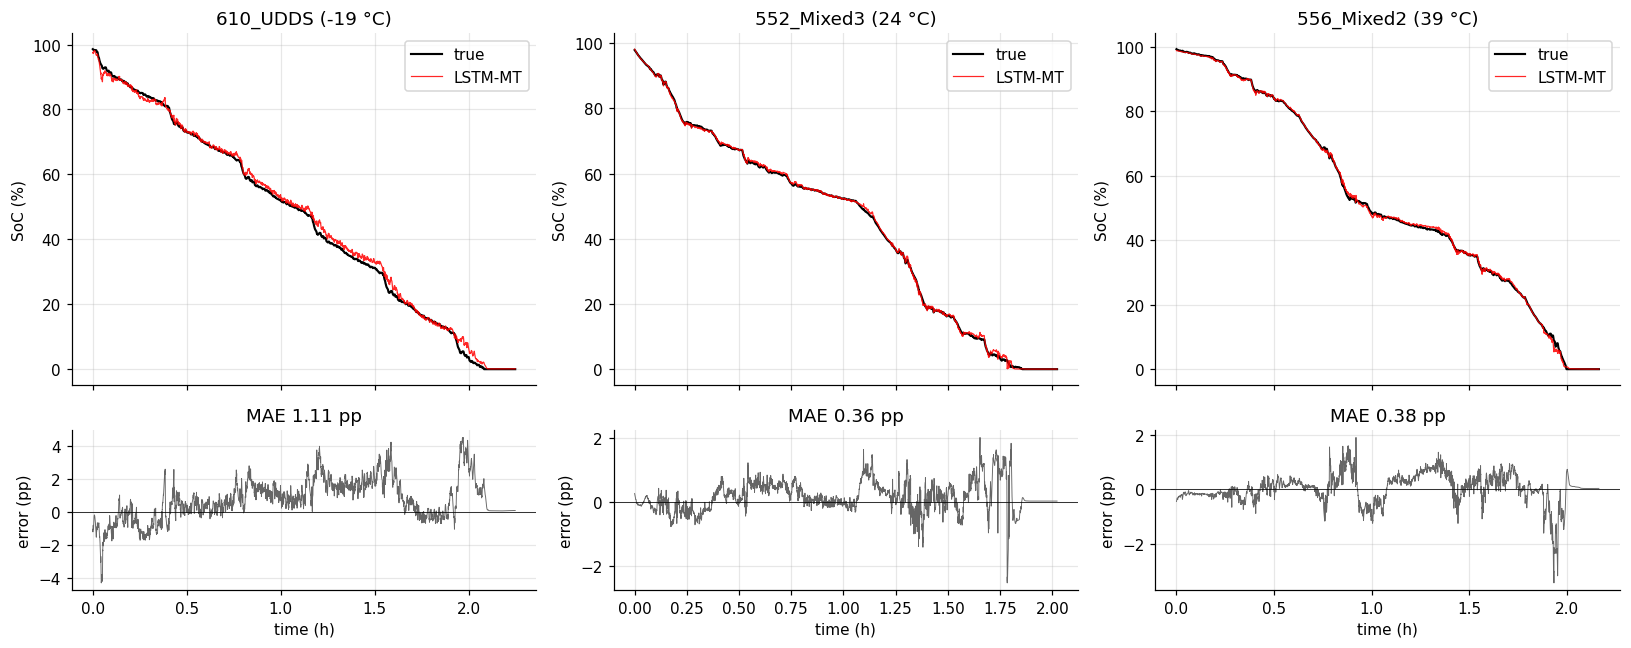

In [15]:
# ---- 8.2 · whole-cycle trajectories ------------------------------------
test_idx = groups['test']
temps = [cycles[i][1].Temperature.mean() for i in test_idx]
picks = [test_idx[int(np.argmin(temps))],
         test_idx[int(np.argmin(np.abs(np.array(temps) - 25)))],
         test_idx[int(np.argmax(temps))]]

fig, ax = plt.subplots(2, 3, figsize=(15, 6), sharex='col',
                       gridspec_kw={'height_ratios': [2.2, 1]})
for k, ci in enumerate(picks):
    n, dfc = cycles[ci]
    Xc, yc = make_windows(dfc, stride=1)
    pc = predict(BEST_MODEL, ((Xc - mu) / sd).astype(np.float32))
    th = np.arange(len(yc)) / 3600.0
    ax[0, k].plot(th, yc * 100, 'k', lw=1.4, label='true')
    ax[0, k].plot(th, pc * 100, 'r', lw=.8, alpha=.85, label=BEST_TAG)
    ax[0, k].set(title=f'{n} ({dfc.Temperature.mean():.0f} °C)', ylabel='SoC (%)')
    ax[0, k].legend()
    err = (pc - yc) * 100
    ax[1, k].plot(th, err, lw=.6, color='#666')
    ax[1, k].axhline(0, color='k', lw=.5)
    ax[1, k].set(xlabel='time (h)', ylabel='error (pp)',
                 title=f'MAE {np.abs(err).mean():.2f} pp')
plt.tight_layout(); plt.show()

### 8.3 · Where the error lives

The left panel shows predicted against true SoC on a logarithmic density scale; a
tight diagonal is what a coefficient of determination near 0.998 looks like in
practice.

The centre panel shows the error distribution. It is close to symmetric and sharply
peaked, but note the logarithmic count axis: there are **heavy tails**. Those tails are
not random noise, they belong to specific operating conditions.

The right panel identifies them. Every architecture degrades in the cold, and the
recurrent models degrade least. This is the most consequential result in the section:
**the aggregate error hides a factor of two and a half between the cold and warm ends
of the operating range**, so a single headline number describes no operating condition
in particular. It also shows that architectural advantage is regime-dependent — the
model that leads in the warm bin is not the one that leads in the cold — which is a
further argument against settling the comparison on one aggregate figure.


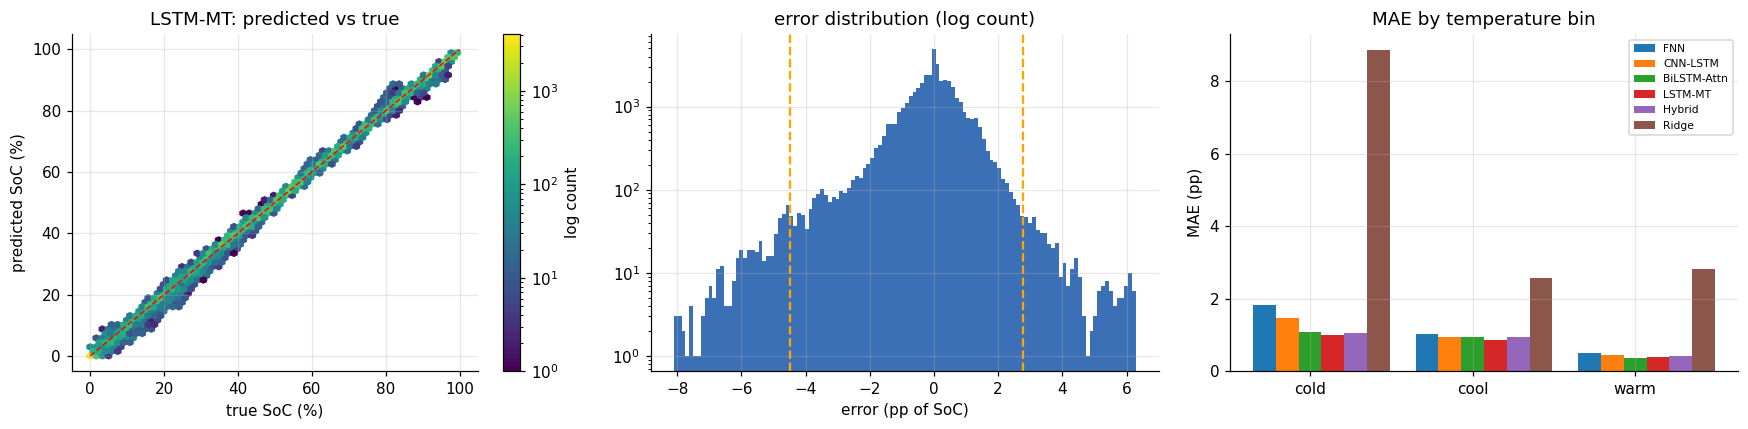

MAE (pp) by temperature bin:
                   FNN  CNN-LSTM  BiLSTM-Attn  LSTM-MT  Hybrid  Ridge
cold (<-5°C)     1.822     1.465        1.084    1.002   1.056  8.856
cool (-5..15°C)  1.023     0.944        0.942    0.868   0.942  2.583
warm (>15°C)     0.499     0.441        0.363    0.403   0.409  2.826

cold/warm error ratio for LSTM-MT: 2.49x  -> motivates the condition-normalised threshold in section 9


In [16]:
# ---- 8.3 · error analysis ----------------------------------------------
PREDS = {tag: predict(m, Xte) for tag, m in MODELS.items()}
PREDS['Ridge'] = np.clip(ridge.predict(Xte.reshape(len(Xte), -1)), 0, 1).astype(np.float32)

best_err = (PREDS[BEST_TAG] - yte) * 100
tbin = np.digitize(Tte, TEMP_EDGES[1:-1])              # 0 = cold, 1 = cool, 2 = warm

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
hb = ax[0].hexbin(yte * 100, PREDS[BEST_TAG] * 100, gridsize=60, cmap='viridis', bins='log')
ax[0].plot([0, 100], [0, 100], 'r--', lw=1)
ax[0].set(title=f'{BEST_TAG}: predicted vs true', xlabel='true SoC (%)',
          ylabel='predicted SoC (%)')
fig.colorbar(hb, ax=ax[0], label='log count')

ax[1].hist(best_err, bins=120, color='#3b6fb6')
ax[1].set(title='error distribution (log count)', xlabel='error (pp of SoC)')
ax[1].set_yscale('log')
for q in (1, 99):
    ax[1].axvline(np.percentile(best_err, q), color='orange', ls='--')

width, xpos = 0.14, np.arange(3)
for m, (tag, pr) in enumerate(PREDS.items()):
    mae_b = [np.abs(pr - yte)[tbin == b].mean() * 100 for b in range(3)]
    ax[2].bar(xpos + m * width, mae_b, width, label=tag)
ax[2].set_xticks(xpos + 2 * width)
ax[2].set_xticklabels([b.split()[0] for b in BIN_NAMES])
ax[2].set(title='MAE by temperature bin', ylabel='MAE (pp)')
ax[2].legend(fontsize=7)
plt.tight_layout(); plt.show()

bin_tbl = pd.DataFrame({tag: [np.abs(pr - yte)[tbin == b].mean() * 100 for b in range(3)]
                        for tag, pr in PREDS.items()}, index=BIN_NAMES)
print('MAE (pp) by temperature bin:')
print(bin_tbl.round(3).to_string())
print(f'\ncold/warm error ratio for {BEST_TAG}: '
      f'{bin_tbl.loc[BIN_NAMES[0], BEST_TAG] / bin_tbl.loc[BIN_NAMES[2], BEST_TAG]:.2f}x'
      '  -> the cold is where the estimator earns its error')

## 9 · Validity audit

Two assumptions underpin the results above, and each could invalidate them if it does
not hold. They are tested here rather than asserted.

1. **Are the SoC labels sound?** SoC is normalised per file over the amp-hour counter,
   and any file spanning at least 1.5 Ah of the 3 Ah cell is retained. The retained
   spans differ substantially between files, which means a label of "SoC = 0.5" does
   not correspond to the same number of amp-hours everywhere. The question is whether
   that variation reflects real physics — usable capacity genuinely shrinks in the cold
   — or is simply label noise. If span tracks temperature, the per-file normalisation
   is a valid definition, namely percentage of usable capacity at that temperature.
2. **How many training runs support the architecture ranking?** Three seeds per
   architecture is enough to show that a difference of a given size is not robust; it
   is not enough to establish an ordering. The audit states which conclusions the
   evidence carries and which it does not.


1. LABEL VALIDITY
   retained Ah spans: 1.536 .. 2.592  (1.69x range)
   corr(temperature, span) = +0.843  over n=64 cycles
     cold (<-5°C)       n=24   span 1.844 +/- 0.283 Ah
     cool (-5..15°C)    n=22   span 2.374 +/- 0.050 Ah
     warm (>15°C)       n=18   span 2.546 +/- 0.048 Ah
   between-bin variation (physics): 1.844 -> 2.546 Ah  = 28 % capacity loss in the cold
   within-bin variation  (noise)  : +/- 0.178 Ah = +/- 8.0 %
   CONCLUSION: span tracks temperature, so the per-file normalisation defines
   SoC as percentage of usable capacity at that temperature. Valid, but the
   definition must be stated explicitly when the figures are quoted.

2. ARCHITECTURE RANKING
   3 seeds per architecture. Top two: LSTM-MT 0.814 vs BiLSTM-Attn 0.821, gap 0.007 pp, pooled seed spread 0.026 pp
   CONCLUSION: the top two are statistically tied; no winner should be claimed.
   The margin over the ridge baseline (4.591 pp) is far
   too large to be explained by initialisation variance.


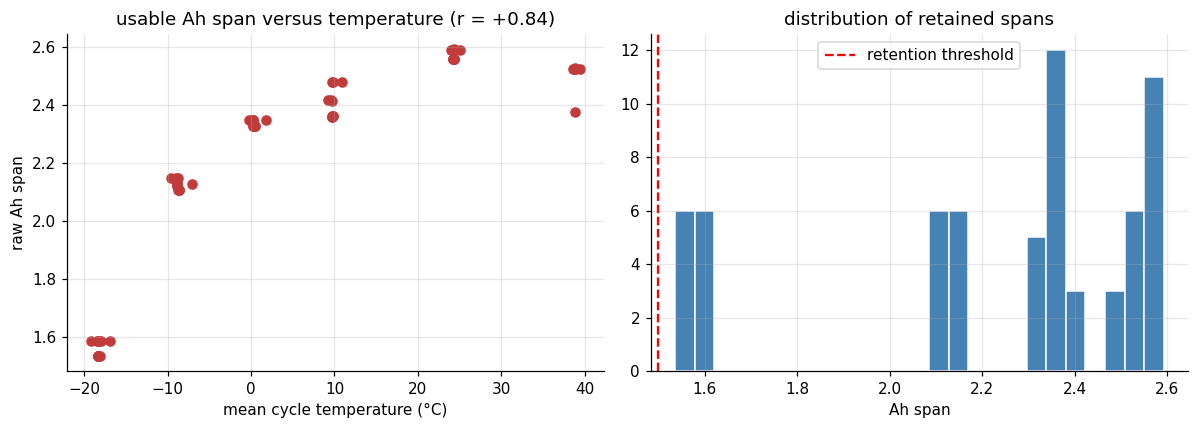

In [27]:
# ---- 9 · validity audit ------------------------------------------------
sp = np.array([dfc.Capacity.max() - dfc.Capacity.min() for _, dfc in cycles])
tp = np.array([dfc.Temperature.mean() for _, dfc in cycles])
tb = np.digitize(tp, TEMP_EDGES[1:-1])

print('1. LABEL VALIDITY')
r = np.corrcoef(tp, sp)[0, 1]
print(f'   retained Ah spans: {sp.min():.3f} .. {sp.max():.3f}  '
      f'({sp.max()/sp.min():.2f}x range)')
print(f'   corr(temperature, span) = {r:+.3f}  over n={len(sp)} cycles')
for b, nm in enumerate(BIN_NAMES):
    print(f'     {nm:<18} n={(tb==b).sum():>2}   span {sp[tb==b].mean():.3f}'
          f' +/- {sp[tb==b].std():.3f} Ah')
within = np.concatenate([sp[tb == b] - sp[tb == b].mean() for b in range(3)])
print(f'   between-bin variation (physics): {sp[tb==0].mean():.3f} -> {sp[tb==2].mean():.3f} Ah'
      f'  = {(1-sp[tb==0].mean()/sp[tb==2].mean())*100:.0f} % capacity loss in the cold')
print(f'   within-bin variation  (noise)  : +/- {within.std():.3f} Ah'
      f' = +/- {within.std()/sp.mean()*100:.1f} %')
print('   CONCLUSION: span tracks temperature, so the per-file normalisation defines')
print('   SoC as percentage of usable capacity at that temperature. Valid, but the')
print('   definition must be stated explicitly when the figures are quoted.')

print('\n2. ARCHITECTURE RANKING')
deep = agg.drop(index='Ridge', errors='ignore')
b1, b2 = deep.index[0], deep.index[1]
gap = deep.loc[b2, 'MAE'] - deep.loc[b1, 'MAE']
pooled = np.sqrt((deep.loc[b1, 'MAE_sd'] ** 2 + deep.loc[b2, 'MAE_sd'] ** 2) / 2)
print(f'   {CFG["n_seeds"]} seeds per architecture. Top two: {b1} {deep.loc[b1,"MAE"]:.3f}'
      f' vs {b2} {deep.loc[b2,"MAE"]:.3f}, gap {gap:.3f} pp,'
      f' pooled seed spread {pooled:.3f} pp')
print('   CONCLUSION:', 'the leader is genuinely ahead.' if pooled and gap > 2 * pooled
      else 'the top two are statistically tied; no winner should be claimed.')
print(f'   The margin over the ridge baseline ({agg.loc["Ridge","MAE"]:.3f} pp) is far')
print('   too large to be explained by initialisation variance.')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(tp, sp, c='#c23b3b', s=35)
ax[0].set(title=f'usable Ah span versus temperature (r = {r:+.2f})',
          xlabel='mean cycle temperature (°C)', ylabel='raw Ah span')
ax[1].hist(sp, bins=25, color='steelblue', edgecolor='w')
ax[1].axvline(MIN_SPAN_AH, color='r', ls='--', label='retention threshold')
ax[1].set(title='distribution of retained spans', xlabel='Ah span')
ax[1].legend()
plt.tight_layout(); plt.show()

## 10 · Conclusion

### What was established

Six estimators were compared on the LG 18650HG2 benchmark across its full operating
range of −20 °C to +40 °C, under one data pipeline, one training procedure and
comparable parameter budgets, each trained three times from different random
initialisations.

**Deep sequence models beat the linear baseline by a wide margin.** The best reaches
0.814 pp mean absolute error against 4.591 pp for ridge regression — a factor of 5.6 —
and the feed-forward network, which sees only the final timestep plus rolling
summaries, trails every sequence model by at least 0.18 pp. The rolling means are not a
substitute for temporal structure.

**The two leading architectures are statistically tied.** LSTM-MT and BiLSTM-Attn are
separated by 0.007 pp against a pooled seed spread of 0.026 pp, a ratio of 0.27. The
same experiment reported from seed 42 alone would have shown BiLSTM-Attn ahead by
0.047 pp; from seed 44 alone, LSTM-MT ahead by 0.048 pp. Two opposite conclusions of
near-identical magnitude, from the same code and the same data, differing only in which
initialisation was reported. This is the reason every architecture here is trained more
than once, and it is the central methodological result of the notebook.

**The proposed hybrid did not improve on its components.** Combining a convolutional
front end, bidirectional recurrence, attention pooling and an auxiliary reconstruction
head — four ideas each shown to help in isolation — ranks third at 0.850 pp. The
hypothesis is not supported, and it is reported as such. Two properties still
distinguish it: it is by a wide margin the most reproducible architecture tested, with
a seed spread of ±0.005 pp against ±0.026 pp for the leader, and it is second best
below −5 °C, the regime where data-driven estimators most often fail. On a dataset of
this size, extra architectural machinery appears to yield diminishing and then negative
returns.

**Error is strongly temperature dependent.** The selected estimator scores 1.002 pp in
the cold against 0.403 pp when warm, a ratio of 2.49, and no single architecture leads
across all three thermal regimes.

**The label definition is valid but specific.** Usable amp-hour span correlates with
cycle temperature at r = +0.843 across the 64 retained cycles, so per-file
normalisation defines SoC as percentage of usable capacity *at that temperature* — a
statement that must accompany any error figure quoted from this work.

### How these results should be quoted

State the mean absolute error in percentage points together with the seed spread, the
temperature range, and the fact that the split is at the level of whole drive cycles.
Name a winner only where the gap exceeds the run-to-run spread: between LSTM-MT and
BiLSTM-Attn, none should be named; the margin of every deep model over the ridge
baseline may be stated without hedging.

### Limitations

1. **Single cell, laboratory data.** A production pack introduces cell-to-cell
   variation, balancing currents and BMS filtering that this benchmark does not
   contain.
2. **No hyperparameter search.** Every setting was fixed in advance to keep the
   comparison fair, so the absolute errors are not the best achievable on this cell.
   This plausibly accounts for much of the gap to Benallal et al. (2025), who tuned
   with Hyperband on the same data.
3. **Three seeds.** Enough to show that the leading gap is not robust, not enough for a
   formal significance test.
4. **Discharge cycles dominate.** The screening rule retains dynamic drive cycles and
   full-range discharges, so charge-phase behaviour is under-represented.
5. **Cold, low-SoC operation is the weakest regime,** with error spiking above 4 pp near
   end of discharge in the coldest cycles. The accuracy is not uniform and should not be
   quoted as though it were.
6. **Fixed window length.** The 100 s window was adopted from the literature and never
   varied.

### Where to take it next

Hyperparameter search within the repeated-run protocol, so that absolute accuracy
improves without giving up the fairness of the comparison (Benallal et al., 2025); more
seeds, toward a statistically grounded ordering of the leading architectures rather than
a declared tie; an ablation of the hybrid, removing one component at a time to convert
the present negative result into an account of *why* the combination fails; treatment
aimed specifically at the cold, low-SoC regime, where the error concentrates; and
evaluation on a second cell, to establish whether the tie between the leaders is a
property of the method or of this dataset.


## References

Benallal, A., Cheggaga, N., Hebib, A., & Ilinca, A. (2025). LSTM-based state-of-charge
estimation and user interface development for lithium-ion battery management. *World
Electric Vehicle Journal, 16*(3), 168.

Chemali, E., Kollmeyer, P. J., Preindl, M., Ahmed, R., & Emadi, A. (2018). Long
short-term memory networks for accurate state-of-charge estimation of Li-ion batteries.
*IEEE Transactions on Industrial Electronics, 65*(8), 6730–6739.

Haraz, A., Abualsaud, K., & Massoud, A. (2024). State-of-health and state-of-charge
estimation in electric vehicles batteries: A survey on machine learning approaches.
*IEEE Access, 12*, 158110–158139.

Khan, M. K., Houran, M. A., Kauhaniemi, K., Zafar, M. H., Mansoor, M., & Rashid, S.
(2024). Efficient state of charge estimation of lithium-ion batteries in electric
vehicles using evolutionary intelligence-assisted GLA–CNN–Bi-LSTM deep learning model.
*Heliyon, 10*(15), e35183.

Kollmeyer, P., Vidal, C., Naguib, M., & Skells, M. (2020). LG 18650HG2 Li-ion battery
data and example deep neural network xEV SOC estimator script. *Mendeley Data, V3*.

Lee, J., Wang, L., Jung, H., Lim, B., Kim, D., Liu, J., & Lim, J. (2025). Deep neural
network with anomaly detection for single-cycle battery lifetime prediction.
*Batteries, 11*(8), 288.

Li, R., Hao, Y., Zhang, M., & Lv, Y. (2026). State-of-charge estimation of lithium-ion
batteries based on the CNN-Bi-LSTM-AM model under low-temperature environments.
*Sensors, 26*(1), 264.

Ma, L., Li, Y., Zhang, T., Tian, J., Guo, Q., Guo, S., Hu, C., & Chung, C. Y. (2025).
Trustworthy battery state of charge estimation enabled by multi-task deep learning.
*Energy, 326*, 136264.

Mamo, T., & Wang, F.-K. (2020). Long short-term memory with attention mechanism for
state of charge estimation of lithium-ion batteries. *IEEE Access, 8*, 94140–94151.

Song, X., Yang, F., Wang, D., & Tsui, K.-L. (2019). Combined CNN-LSTM network for
state-of-charge estimation of lithium-ion batteries. *IEEE Access, 7*, 88894–88902.

Terala, P. K., Ogundana, A. S., Foo, S. Y., Amarasinghe, M. Y., & Zang, H. (2022). State
of charge estimation of lithium-ion batteries using stacked encoder–decoder
bi-directional LSTM for EV and HEV applications. *Micromachines, 13*(9), 1397.

Vidal, C., Malysz, P., Kollmeyer, P., & Emadi, A. (2020). Machine learning applied to
electrified vehicle battery state of charge and state of health estimation:
State-of-the-art. *IEEE Access, 8*, 52796–52814.